In [14]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
#Add target (between 25 and 346)
df['target']=diabetes.target
df.head(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346,97.0
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0


In [15]:
#Split data into X (features) and y (target)
X = df.drop('target', axis=1)
y = df['target']


In [21]:
X.shape, y.shape



((442, 10), (442,))

In [30]:
from sklearn.model_selection import train_test_split
#split data into training 80% and test 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


In [34]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()


In [35]:
#train lr
lr.fit(X_train, y_train)
lr.predict()

LinearRegression()

In [37]:
#predict y (target) based on testing features (80% of data)
y_pred = lr.predict(X_test)
y_pred

array([139.5475584 , 179.51720835, 134.03875572, 291.41702925,
       123.78965872,  92.1723465 , 258.23238899, 181.33732057,
        90.22411311, 108.63375858,  94.13865744, 168.43486358,
        53.5047888 , 206.63081659, 100.12925869, 130.66657085,
       219.53071499, 250.7803234 , 196.3688346 , 218.57511815,
       207.35050182,  88.48340941,  70.43285917, 188.95914235,
       154.8868162 , 159.36170122, 188.31263363, 180.39094033,
        47.99046561, 108.97453871, 174.77897633,  86.36406656,
       132.95761215, 184.53819483, 173.83220911, 190.35858492,
       124.4156176 , 119.65110656, 147.95168682,  59.05405241,
        71.62331856, 107.68284704, 165.45365458, 155.00975931,
       171.04799096,  61.45761356,  71.66672581, 114.96732206,
        51.57975523, 167.57599528, 152.52291955,  62.95568515,
       103.49741722, 109.20751489, 175.64118426, 154.60296242,
        94.41704366, 210.74209145, 120.2566205 ,  77.61585399,
       187.93203995, 206.49337474, 140.63167076, 105.59

In [43]:
#Compare predicted target to tested data and get metrics of success:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
#value of dependant variable (target) when the independant variables (features) are 0 
#   When positive, target increases as features increase, if it is negative, the opposite.
intercept = lr.intercept_

print('R2 Score 0 to 1: ', r2, ' - Higher is better' )
print('Mean Squared Error: ', mse, ' - Average squared distance between predicted and tested - lower is better' )
print('Mean Absolute Error: ', mae, ' - Average ABS distance between predicted and tested - lower is better' )
print('Intercept: ', intercept, ' - Since positive, chance of diabetes increases with age ' )

R2 Score 0 to 1:  0.45260276297191915  - Higher is better
Mean Squared Error:  2900.1936284934827  - Average squared distance between predicted and tested - lower is better
Mean Absolute Error:  42.794094679599944  - Average ABS distance between predicted and tested - lower is better
Intercept:  151.34560453985995  - Since positive, chance of diabetes increases with age 


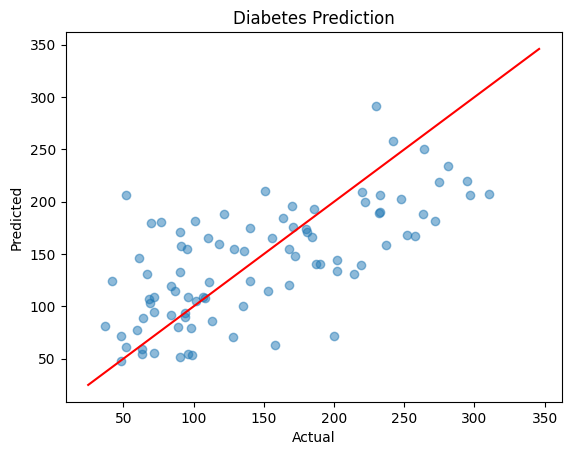

In [62]:
import matplotlib.pyplot as plt

# show plot where X is actual values and Y is the predicted values
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Diabetes Prediction')

plt.show()

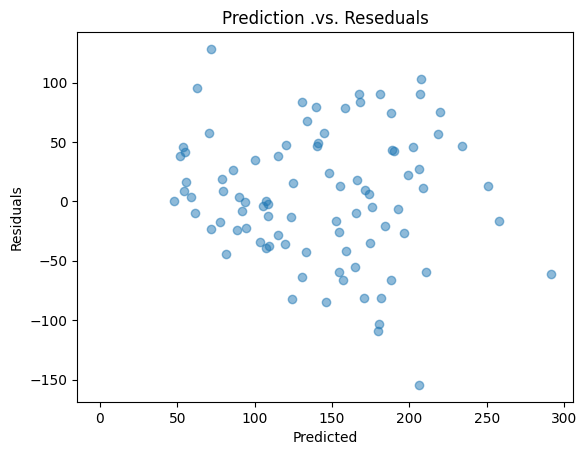

In [68]:
#plot resedual - expected to be random spread - not clustered arround 0
plt.scatter(y_pred, y_test - y_pred, alpha=0.5)
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Prediction .vs. Reseduals')
plt.show()